# Area Classifier

**Nessun prerequisito Colab in questa fase** — gli embedding sono già stati calcolati su GPU (Colab) e salvati come file `.npy`.

### Pipeline
1. Carica i 4 file `.npy` dalla cartella `embeddings/`
2. Verifica allineamento e normalizzazione L2
3. Tuning C con 3-fold CV
4. Training LinearSVC + valutazione
5. Salvataggio in `modelli/area_v2/`

### File richiesti in `embeddings/`
```
area_v2_e5_train.npy       ← embedding train  (n_train × 768)
area_v2_e5_test.npy        ← embedding test   (n_test  × 768)
area_v2_labels_train.npy   ← label train      (array di stringhe)
area_v2_labels_test.npy    ← label test       (array di stringhe)

---
## STEP 1 — Import e configurazione percorsi

In [1]:
import pandas as pd
import numpy as np
import warnings
import time
import os
from pathlib import Path
warnings.filterwarnings('ignore')

BASE_DIR = Path(os.path.abspath('')).parent

DATA_DIR = BASE_DIR / 'data'
EMB_DIR  = BASE_DIR / 'embeddings'
MOD_DIR  = BASE_DIR / 'modelli'

CSV_PATH          = DATA_DIR / 'dataset_clean.csv'
EMB_TRAIN_PATH    = EMB_DIR  / 'area_v3_e5_train.npy'
EMB_TEST_PATH     = EMB_DIR  / 'area_v3_e5_test.npy'
LABELS_TRAIN_PATH = EMB_DIR  / 'area_v3_labels_train.npy'
LABELS_TEST_PATH  = EMB_DIR  / 'area_v3_labels_test.npy'

SOGLIA_SPLIT = '2025-11-01'

print(f'BASE_DIR : {BASE_DIR}')
print()
for p in [CSV_PATH, EMB_TRAIN_PATH, EMB_TEST_PATH, LABELS_TRAIN_PATH, LABELS_TEST_PATH]:
    stato = 'OK' if p.exists() else 'MANCANTE ⚠️'
    print(f'  {p.name:<40} {stato}')

BASE_DIR : c:\Users\matteo.segatto\Desktop\TicketClassifier

  dataset_clean.csv                        OK
  area_v3_e5_train.npy                     OK
  area_v3_e5_test.npy                      OK
  area_v3_labels_train.npy                 OK
  area_v3_labels_test.npy                  OK


---
## STEP 2 — Pulizia classi area (v2)

Riproduciamo qui la logica di preprocessing che viveva su Colab, per documentazione e riproducibilità.
Rinomina: Hardware → area_sistemistica
Drop: business_intelligence e protocollo_delibere
Drop classi con < 10 ticket totali 
> **Nota**: questa cella è solo documentazione — `y_train` e `y_test` vengono caricati dai file `.npy` nel passo successivo, garantendo allineamento perfetto con gli embedding.

In [2]:
# Carico il CSV per applicare la pulizia e mostrare la distribuzione finale
df = pd.read_csv(CSV_PATH, parse_dates=['data_creazione'])

# 1. Rinomino Hardware → area_sistemistica
df['area_v2'] = df['area'].replace({'Hardware': 'area_sistemistica'})

# 2. Droppo classi irrecuperabili
CLASSI_DROP = ['business_intelligence', 'protocollo_delibere']
df.loc[df['area_v2'].isin(CLASSI_DROP), 'area_v2'] = np.nan

# 3. Droppo classi con meno di 10 ticket (rumore statistico)
conteggi = df['area_v2'].value_counts()
classi_rumore = conteggi[conteggi < 10].index.tolist()
if classi_rumore:
    print(f'Classi droppate per rumore (< 10 ticket): {classi_rumore}')
    df.loc[df['area_v2'].isin(classi_rumore), 'area_v2'] = np.nan

# 4. Split temporale (stesso usato in Colab per generare gli .npy)
df_validi   = df.dropna(subset=['area_v2'])
df_train_doc = df_validi[df_validi['data_creazione'] < SOGLIA_SPLIT]
df_test_doc  = df_validi[df_validi['data_creazione'] >= SOGLIA_SPLIT]

print('=== Distribuzione area_v2 — dataset completo ===')
print(df['area_v2'].value_counts(dropna=False).to_string())
print()
print(f'Ticket usabili (area_v2 valorizzata): {len(df_validi):,}')
print(f'  → Train (< {SOGLIA_SPLIT}): {len(df_train_doc):,}')
print(f'  → Test  (≥ {SOGLIA_SPLIT}): {len(df_test_doc):,}')
print()
print('(y_train e y_test vengono dai file .npy — questo blocco è solo documentazione)')

Classi droppate per rumore (< 10 ticket): ['Amministrazione', 'Personale', 'CSS', 'Utenti e Ospiti', 'flussi_regionali']
=== Distribuzione area_v2 — dataset completo ===
area_v2
area_personale                     14251
ciclo_passivo                      10991
ciclo_attivo                        9233
area_sanitaria                      8747
NaN                                 6236
rendicontazione_flussi              2854
protocollo_documentale_delibere     2580
area_sistemistica                   1951
sistema381                          1006
area_territoriale                    536

Ticket usabili (area_v2 valorizzata): 52,149
  → Train (< 2025-11-01): 41,828
  → Test  (≥ 2025-11-01): 10,321

(y_train e y_test vengono dai file .npy — questo blocco è solo documentazione)


---
## STEP 3 — Caricamento embedding e label

Carico direttamente i 4 file `.npy` prodotti dal Colab.
Label e embedding sono garantiti allineati perché generati insieme.

In [3]:
for p in [EMB_TRAIN_PATH, EMB_TEST_PATH, LABELS_TRAIN_PATH, LABELS_TEST_PATH]:
    if not p.exists():
        raise FileNotFoundError(
            f'File non trovato: {p}\n'
            f'Scarica i file .npy da Colab e mettili in: {EMB_DIR}'
        )

X_train = np.load(EMB_TRAIN_PATH)
X_test  = np.load(EMB_TEST_PATH)
y_train = np.load(LABELS_TRAIN_PATH, allow_pickle=True)
y_test  = np.load(LABELS_TEST_PATH,  allow_pickle=True)

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_train : {y_train.shape}')
print(f'y_test  : {y_test.shape}')

X_train : (41828, 768)
X_test  : (10321, 768)
y_train : (41828,)
y_test  : (10321,)


---
## STEP 3b — OHE `priorita_iniziale_cliente` + costruzione feature matrix finale

Concatena alla matrice degli embedding una feature one-hot per `priorita_iniziale_cliente`.  
NaN → vettore di zeri (gestito automaticamente da `handle_unknown='ignore'`).

In [4]:
import scipy.sparse as sp
from sklearn.preprocessing import OneHotEncoder

# ── OHE priorita_iniziale_cliente ─────────────────────────────────────────────
CAT_COLS = ['priorita_iniziale_cliente']

encoder_cat = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
encoder_cat.fit(df_train_doc[CAT_COLS])

X_cat_train = encoder_cat.transform(df_train_doc[CAT_COLS])
X_cat_test  = encoder_cat.transform(df_test_doc[CAT_COLS])

print(f'Feature OHE priorità: {X_cat_train.shape[1]} colonne')
print(f'  Categorie: {encoder_cat.categories_[0].tolist()}')

# ── Keyword booleane ──────────────────────────────────────────────────────────
# Colonne binarie aggiunte al CSV dal preprocessing (STEP 9b).
# Coprono le 4 classi con F1 più basso: sistema381, area_territoriale,
# ciclo_passivo, ciclo_attivo.
KW_COLS = [c for c in df_train_doc.columns if c.startswith('kw_')]
print(f'\nFeature keyword: {len(KW_COLS)} colonne')
print(f'  {KW_COLS}')

# Convertiamo le colonne bool in matrice sparsa (0/1)
X_kw_train = sp.csr_matrix(df_train_doc[KW_COLS].astype(float).values)
X_kw_test  = sp.csr_matrix(df_test_doc[KW_COLS].astype(float).values)

# ── Costruzione feature matrix finale ─────────────────────────────────────────
# [embedding 768d | OHE priorità 4d | keyword booleane 18d]
X_train = sp.hstack([sp.csr_matrix(X_train), X_cat_train, X_kw_train])
X_test  = sp.hstack([sp.csr_matrix(X_test),  X_cat_test,  X_kw_test])

print(f'\nFeature matrix train: {X_train.shape}')
print(f'Feature matrix test:  {X_test.shape}')
print(f'  embedding: 768  |  OHE: {X_cat_train.shape[1]}  |  keyword: {len(KW_COLS)}  |  totale: {X_train.shape[1]}')

Feature OHE priorità: 4 colonne
  Categorie: ['P1', 'P2', 'P3', 'P4']

Feature keyword: 18 colonne
  ['kw_s381_codice', 'kw_s381_rapportino', 'kw_s381_timbrate', 'kw_s381_calendario_presenze', 'kw_ter_unodomo', 'kw_ter_distretto', 'kw_pas_iva', 'kw_pas_fornitore', 'kw_pas_cespiti', 'kw_pas_prima_nota', 'kw_pas_ammortamento', 'kw_pas_analitica', 'kw_pas_reverse', 'kw_att_retta', 'kw_att_pagopa', 'kw_att_sdd', 'kw_att_portale_utenti', 'kw_att_fattura_elettronica']

Feature matrix train: (41828, 790)
Feature matrix test:  (10321, 790)
  embedding: 768  |  OHE: 4  |  keyword: 18  |  totale: 790


---
## STEP 4 — Verifica allineamento e distribuzione classi

In [5]:
# X_train/X_test sono ora sparse matrix → usare .shape[0] invece di len()
assert X_train.shape[0] == len(y_train), f'MISMATCH TRAIN: {X_train.shape[0]} emb vs {len(y_train)} label'
assert X_test.shape[0]  == len(y_test),  f'MISMATCH TEST:  {X_test.shape[0]} emb vs {len(y_test)} label'
print('Allineamento OK')
print()

# Verifica normalizzazione L2 sui primi 768d (embedding) — gli altri sono 0/1
# .toarray() necessario per passare da sparse a numpy
norme = np.linalg.norm(X_train[:5, :768].toarray(), axis=1)
print(f'Norma L2 primi 5 vettori train (atteso ~1.0): {norme.round(4)}')
print()

print('Classi nel train:')
print(pd.Series(y_train).value_counts().to_string())
print()
print('Classi nel test:')
print(pd.Series(y_test).value_counts().to_string())

Allineamento OK

Norma L2 primi 5 vettori train (atteso ~1.0): [1. 1. 1. 1. 1.]

Classi nel train:
area_personale                     11087
ciclo_passivo                       8927
ciclo_attivo                        7359
area_sanitaria                      7323
rendicontazione_flussi              2459
protocollo_documentale_delibere     1896
area_sistemistica                   1500
sistema381                           834
area_territoriale                    443

Classi nel test:
area_personale                     3164
ciclo_passivo                      2064
ciclo_attivo                       1874
area_sanitaria                     1424
protocollo_documentale_delibere     684
area_sistemistica                   451
rendicontazione_flussi              395
sistema381                          172
area_territoriale                    93


---
## STEP 5 — Tuning parametro C con cross-validation

`C` controlla il tradeoff bias/varianza in LinearSVC:
- **C piccolo** → forte regolarizzazione, margine largo, rischio underfitting
- **C grande** → poca regolarizzazione, rischio overfitting

Con embedding L2-normalizzati i valori ottimali tipici stanno tra 0.5 e 10.  
Usiamo 3-fold CV per velocità — su ~40k ticket è già robusto.

In [6]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score, StratifiedKFold

VALORI_C = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

# StratifiedKFold mantiene la proporzione delle classi in ogni fold,
# importante per classi piccole come area_territoriale
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print('Tuning parametro C — LinearSVC (3-fold CV, metrica: macro F1)')
print(f'{"C":>6}  {"F1 macro":>10}  {"Std":>8}  {"Tempo":>8}')
print('-' * 42)

risultati_c = {}
for c in VALORI_C:
    clf_tmp = LinearSVC(class_weight='balanced', max_iter=3000, C=c, random_state=42)
    t0 = time.time()
    scores = cross_val_score(
        clf_tmp, X_train, y_train,
        cv=cv, scoring='f1_macro', n_jobs=-1
    )
    elapsed = time.time() - t0
    risultati_c[c] = scores.mean()
    print(f'{c:>6.1f}  {scores.mean():>10.4f}  {scores.std():>8.4f}  {elapsed:>7.0f}s')

C_OTTIMALE = max(risultati_c, key=risultati_c.get)
print(f'\nC ottimale selezionato: {C_OTTIMALE}  (F1 macro = {risultati_c[C_OTTIMALE]:.4f})')

Tuning parametro C — LinearSVC (3-fold CV, metrica: macro F1)
     C    F1 macro       Std     Tempo
------------------------------------------
   0.1      0.6610    0.0064       66s
   0.5      0.6755    0.0027       71s
   1.0      0.6792    0.0060       77s
   2.0      0.6841    0.0059       85s
   5.0      0.6859    0.0035       96s
  10.0      0.6862    0.0038      113s

C ottimale selezionato: 10.0  (F1 macro = 0.6862)


---
## STEP 6 — Training e valutazione finale

In [7]:
from sklearn.metrics import classification_report, f1_score

print(f'Training LinearSVC con C={C_OTTIMALE}...')
t0 = time.time()

clf_final = LinearSVC(
    class_weight='balanced',
    C=C_OTTIMALE,
    max_iter=3000,
    random_state=42
)
clf_final.fit(X_train, y_train)
print(f'Training completato in {time.time() - t0:.1f}s')
print()

y_pred = clf_final.predict(X_test)
macro_f1 = f1_score(y_test, y_pred, average='macro')
accuracy  = (y_pred == y_test).mean()

print(f'{"="*60}')
print(f'RISULTATI AREA CLASSIFIER v2 (E5-base + LinearSVC)')
print(f'{"="*60}')
print(f'Macro F1:  {macro_f1:.4f}')
print(f'Accuracy:  {accuracy:.4f}')
print()
print(classification_report(y_test, y_pred, zero_division=0))

Training LinearSVC con C=10.0...
Training completato in 125.8s

RISULTATI AREA CLASSIFIER v2 (E5-base + LinearSVC)
Macro F1:  0.6647
Accuracy:  0.7561

                                 precision    recall  f1-score   support

                 area_personale       0.91      0.84      0.87      3164
                 area_sanitaria       0.76      0.76      0.76      1424
              area_sistemistica       0.42      0.64      0.51       451
              area_territoriale       0.30      0.57      0.39        93
                   ciclo_attivo       0.74      0.66      0.70      1874
                  ciclo_passivo       0.79      0.71      0.74      2064
protocollo_documentale_delibere       0.76      0.85      0.80       684
         rendicontazione_flussi       0.61      0.83      0.71       395
                     sistema381       0.40      0.67      0.50       172

                       accuracy                           0.76     10321
                      macro avg       0.63 

---
## STEP 7 — Confusion matrix e analisi errori

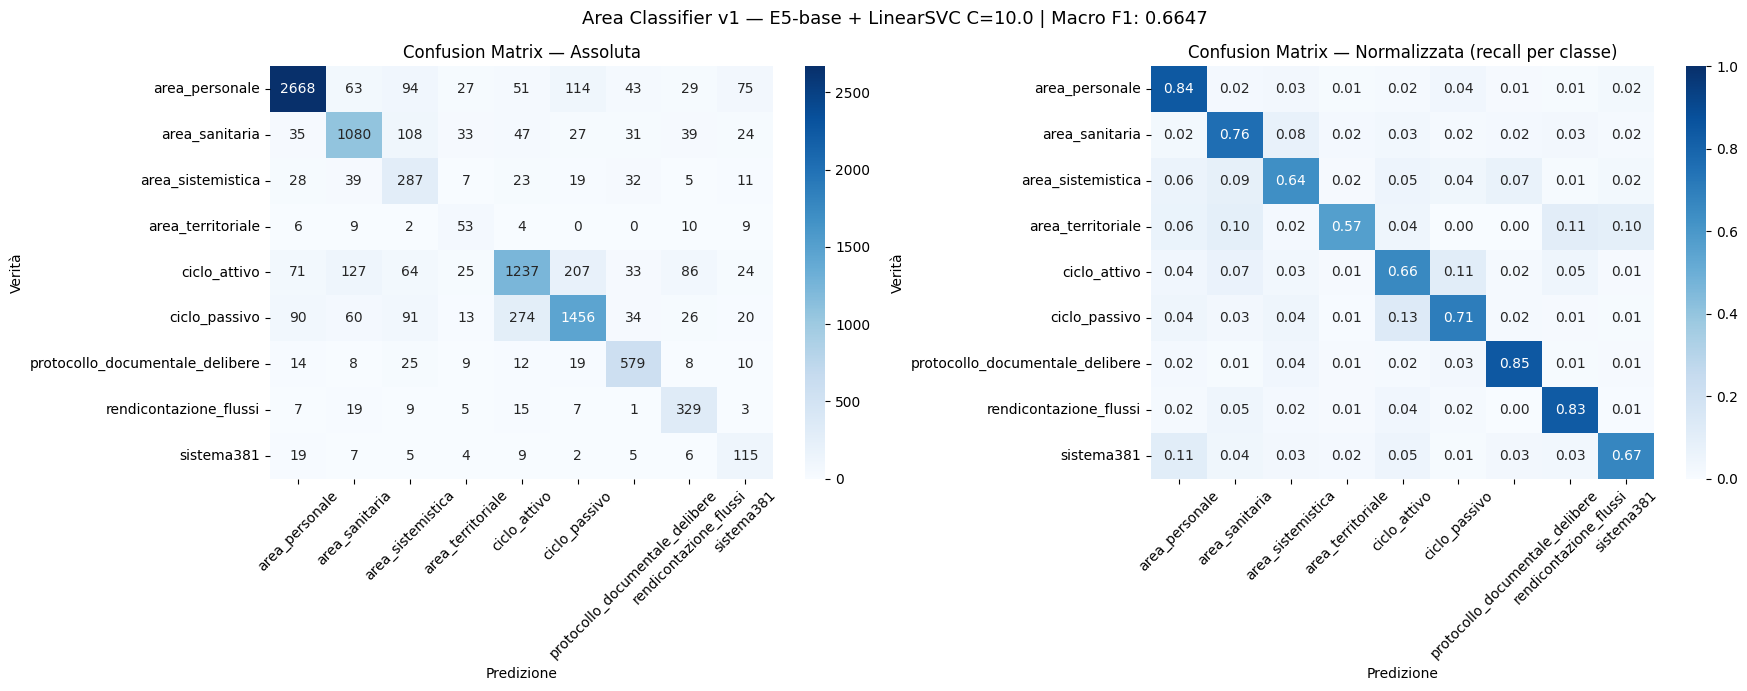

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

classi_ordinate = sorted(clf_final.classes_)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Confusion matrix assoluta ---
cm_abs = confusion_matrix(y_test, y_pred, labels=classi_ordinate)
sns.heatmap(
    cm_abs, annot=True, fmt='d', cmap='Blues',
    xticklabels=classi_ordinate, yticklabels=classi_ordinate,
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix — Assoluta')
axes[0].set_xlabel('Predizione')
axes[0].set_ylabel('Verità')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# --- Confusion matrix normalizzata (recall per classe) ---
cm_norm = confusion_matrix(y_test, y_pred, labels=classi_ordinate, normalize='true')
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=classi_ordinate, yticklabels=classi_ordinate,
    ax=axes[1], vmin=0, vmax=1
)
axes[1].set_title('Confusion Matrix — Normalizzata (recall per classe)')
axes[1].set_xlabel('Predizione')
axes[1].set_ylabel('Verità')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle(f'Area Classifier v1 — E5-base + LinearSVC C={C_OTTIMALE} | Macro F1: {macro_f1:.4f}', fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
# ---------------------------------------------------------------------------
# TOP COPPIE DI CONFUSIONE
# Mostra quali classi vengono confuse tra loro
# ---------------------------------------------------------------------------
df_err = pd.DataFrame({'reale': y_test, 'predetto': y_pred})
errori = df_err[df_err['reale'] != df_err['predetto']]

print(f'Errori totali: {len(errori):,} su {len(y_test):,} ({len(errori)/len(y_test)*100:.1f}%)')
print()
print('Top 15 coppie di confusione (reale → predetto):')
print(
    errori.groupby(['reale', 'predetto'])
    .size()
    .sort_values(ascending=False)
    .head(15)
    .to_string()
)

Errori totali: 2,517 su 10,321 (24.4%)

Top 15 coppie di confusione (reale → predetto):
reale           predetto              
ciclo_passivo   ciclo_attivo              274
ciclo_attivo    ciclo_passivo             207
                area_sanitaria            127
area_personale  ciclo_passivo             114
area_sanitaria  area_sistemistica         108
area_personale  area_sistemistica          94
ciclo_passivo   area_sistemistica          91
                area_personale             90
ciclo_attivo    rendicontazione_flussi     86
area_personale  sistema381                 75
ciclo_attivo    area_personale             71
                area_sistemistica          64
area_personale  area_sanitaria             63
ciclo_passivo   area_sanitaria             60
area_personale  ciclo_attivo               51


---
## STEP 8 — Analisi errori approfondita

Ricostruiamo il DataFrame di test con il testo originale per capire **dove** e **perché** sbaglia il modello.

In [10]:
import re

# df_test_doc è già stato costruito in STEP 2 — usiamo quello direttamente
df_test_err = df_test_doc.reset_index(drop=True).copy()

print(f'Righe test dal CSV : {len(df_test_err):,}')
print(f'y_test (.npy)      : {len(y_test):,}')
print()
print('Colonne disponibili:', df_test_err.columns.tolist())

# Verifica allineamento righe CSV e .npy
if len(df_test_err) != len(y_test):
    print('\n⚠️  MISMATCH — righe test CSV e .npy non coincidono.')
    print('   Soluzione: salva gli indici dal Colab e ricaricali qui.')
else:
    df_test_err['label_reale']    = y_test
    df_test_err['label_predetta'] = y_pred
    df_test_err['corretto']       = df_test_err['label_reale'] == df_test_err['label_predetta']

    n_err = (~df_test_err['corretto']).sum()
    print(f'\nAllineamento OK ✓')
    print(f'Errori: {n_err:,} / {len(df_test_err):,} ({n_err/len(df_test_err)*100:.1f}%)')

Righe test dal CSV : 10,321
y_test (.npy)      : 10,321

Colonne disponibili: ['url_ticket', 'case_number', 'testo_input', 'priorita_finale', 'priorita_iniziale_cliente', 'area', 'articolo', 'modulo_sw', 'has_urgenza', 'n_parole', 'data_creazione', 'kw_s381_codice', 'kw_s381_rapportino', 'kw_s381_timbrate', 'kw_s381_calendario_presenze', 'kw_ter_unodomo', 'kw_ter_distretto', 'kw_pas_iva', 'kw_pas_fornitore', 'kw_pas_cespiti', 'kw_pas_prima_nota', 'kw_pas_ammortamento', 'kw_pas_analitica', 'kw_pas_reverse', 'kw_att_retta', 'kw_att_pagopa', 'kw_att_sdd', 'kw_att_portale_utenti', 'kw_att_fattura_elettronica', 'area_v2']

Allineamento OK ✓
Errori: 2,517 / 10,321 (24.4%)


In [11]:
# ── Analisi lessicale: parole che il modello confonde ───────────────────────
# Per ogni coppia (reale → predetto), trova le parole più frequenti nei ticket
# sbagliati VS nei ticket correttamente classificati della stessa classe.

from collections import Counter

COPPIE_ANALISI = [
    ('ciclo_passivo',  'ciclo_attivo'),
    ('ciclo_attivo',   'ciclo_passivo'),
    ('area_personale', 'sistema381'),
    ('area_sanitaria', 'area_sistemistica'),
]

STOPWORDS = {
    'il', 'lo', 'la', 'i', 'gli', 'le', 'un', 'una', 'di', 'del', 'della',
    'dei', 'degli', 'delle', 'da', 'dal', 'dalla', 'a', 'al', 'alla', 'in',
    'nel', 'nella', 'nei', 'su', 'sul', 'sulla', 'con', 'per', 'tra', 'fra',
    'che', 'non', 'si', 'è', 'e', 'ma', 'o', 'se', 'come', 'anche', 'più',
    'questo', 'questa', 'questi', 'queste', 'ho', 'ha', 'sono', 'essere',
    'ci', 'mi', 'ti', 'vi', 'ne', 'salve', 'buongiorno', 'buonasera',
    'grazie', 'cordiali', 'saluti',
}

# Funzione di tokenizzazione semplice: minuscolo, rimuove punteggiatura, filtra stopwords e parole corte
def tokenizza(testo):
    testo = str(testo).lower()
    testo = re.sub(r'[^a-zàáèéìíòóùú\s]', ' ', testo)
    return [w for w in testo.split() if len(w) > 3 and w not in STOPWORDS]

# Analisi per ogni coppia di confusione
for reale, predetto in COPPIE_ANALISI:
    mask_errore   = (df_test_err['label_reale'] == reale) & (df_test_err['label_predetta'] == predetto)
    mask_corretto = (df_test_err['label_reale'] == reale) & (df_test_err['corretto'])

    testi_err = df_test_err.loc[mask_errore,   'testo_input']
    testi_ok  = df_test_err.loc[mask_corretto, 'testo_input']

    if len(testi_err) == 0:
        continue

    cnt_err = Counter(w for t in testi_err for w in tokenizza(t))
    cnt_ok  = Counter(w for t in testi_ok  for w in tokenizza(t))
    n_err_pair = len(testi_err)
    n_ok_pair  = len(testi_ok)

    parole_sospette = []
    for parola, freq_e in cnt_err.items():
        freq_o  = cnt_ok.get(parola, 0)
        ratio_e = freq_e / n_err_pair
        ratio_o = freq_o / max(n_ok_pair, 1)
        if ratio_e >= 0.05 and ratio_e > ratio_o * 1.5:
            parole_sospette.append((parola, freq_e, round(ratio_e, 3), round(ratio_o, 3)))

    parole_sospette.sort(key=lambda x: -x[2])

    print(f'{"─"*60}')
    print(f'REALE: {reale}  →  PREDETTO: {predetto}  ({n_err_pair} errori)')
    print(f'{"Parola":<20} {"Freq err":>9} {"Ratio err":>10} {"Ratio ok":>9}')
    for p, f, re_, ro in parole_sospette[:15]:
        print(f'{p:<20} {f:>9} {re_:>10.3f} {ro:>9.3f}')
    print()

────────────────────────────────────────────────────────────
REALE: ciclo_passivo  →  PREDETTO: ciclo_attivo  (274 errori)
Parola                Freq err  Ratio err  Ratio ok
fatture                    203      0.741     0.380
fatturazione               103      0.376     0.040
elettronica                103      0.376     0.049
elettroniche                49      0.179     0.052
invio                       48      0.175     0.072
codice                      44      0.161     0.096
sistema                     40      0.146     0.061
aggiornamento               36      0.131     0.055
nell                        36      0.131     0.078
allego                      34      0.124     0.080
credenziali                 29      0.106     0.012
servizio                    28      0.102     0.019
canale                      28      0.102     0.008
modifica                    27      0.099     0.034
sanitaria                   23      0.084     0.022

────────────────────────────────────────────

---
## STEP 8 — Salvataggio modello

In [12]:
import joblib
import json

SAVE_DIR = MOD_DIR / 'area_v2'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(clf_final,   SAVE_DIR / 'classificatore_svc.pkl')
joblib.dump(encoder_cat, SAVE_DIR / 'encoder_cat.pkl')

metadata = {
    'versione': 'v2',
    'modello_embedding': 'intfloat/multilingual-e5-base',
    'prefisso_e5': 'query: ',
    'classificatore': 'LinearSVC',
    'C_ottimale': C_OTTIMALE,
    'class_weight': 'balanced',
    'feature': [
        'embedding_e5_768d',
        'ohe_priorita_iniziale_cliente',
        'keyword_booleane',
    ],
    'keyword_cols': KW_COLS,
    'classi': clf_final.classes_.tolist(),
    'split': 'temporale',
    'soglia_split': SOGLIA_SPLIT,
    'macro_f1_test': round(float(macro_f1), 4),
    'accuracy_test': round(float(accuracy), 4),
    'n_train': int(len(y_train)),
    'n_test': int(len(y_test)),
    'note': 'Hardware accorpato in area_sistemistica; business_intelligence e protocollo_delibere droppati'
}

with open(SAVE_DIR / 'metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f'Modello salvato in: {SAVE_DIR}')
print()
print(json.dumps(metadata, indent=2, ensure_ascii=False))

Modello salvato in: c:\Users\matteo.segatto\Desktop\TicketClassifier\modelli\area_v2

{
  "versione": "v2",
  "modello_embedding": "intfloat/multilingual-e5-base",
  "prefisso_e5": "query: ",
  "classificatore": "LinearSVC",
  "C_ottimale": 10.0,
  "class_weight": "balanced",
  "feature": [
    "embedding_e5_768d",
    "ohe_priorita_iniziale_cliente",
    "keyword_booleane"
  ],
  "keyword_cols": [
    "kw_s381_codice",
    "kw_s381_rapportino",
    "kw_s381_timbrate",
    "kw_s381_calendario_presenze",
    "kw_ter_unodomo",
    "kw_ter_distretto",
    "kw_pas_iva",
    "kw_pas_fornitore",
    "kw_pas_cespiti",
    "kw_pas_prima_nota",
    "kw_pas_ammortamento",
    "kw_pas_analitica",
    "kw_pas_reverse",
    "kw_att_retta",
    "kw_att_pagopa",
    "kw_att_sdd",
    "kw_att_portale_utenti",
    "kw_att_fattura_elettronica"
  ],
  "classi": [
    "area_personale",
    "area_sanitaria",
    "area_sistemistica",
    "area_territoriale",
    "ciclo_attivo",
    "ciclo_passivo",
    "pro